# Øvingsoppgaver 4 – Klassifisering
Data Mining & Analytics – Samling 2, dag 2

Datasett: Pima Indians Diabetes 
Mål: predikere om personen har diabetes (`class`). Tenk deg at modellen skal brukes til screening. Må derfor vurdere hva som er mest problematisk: overse en syk, eller å kalle inn en frisk til ekstra testing?

In [ ]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(1)


data = pd.read_csv("../Data/data.csv")
data["diabetes"] = (data["class"] == "tested_positive").astype(int)
data = data.drop(columns="class")
data.head()

,preg,plas,pres,skin,insu,mass,pedi,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Oppgave 1 – Utforsk og baseline
- a) Hvor stor andel har diabetes? Hva blir nøyaktigheten til en modell som alltid sier «ingen diabetes»?
- b) Se på minimumsverdiene. Hvilke variabler har urealistiske nullverdier (f.eks. blodtrykk = 0)? Hvor mange? Hvilken strategi kan vi velge for å håndtere dette?

In [ ]:
print("Andel diabetes:", data["diabetes"].mean().round(3))
dum = DummyClassifier(strategy="most_frequent").fit(data.drop(columns="diabetes"), data["diabetes"])
print("Nøyaktighet 'alltid negativ':", round(dum.score(data.drop(columns="diabetes"), data["diabetes"]), 3))
kol = ["plas", "pres", "skin", "insu", "mass"]
print((data[kol] == 0).sum())

Andel diabetes: 0.349
Nøyaktighet 'alltid negativ': 0.651
plas      5
pres     35
skin    227
insu    374
mass     11
dtype: int64


35 % har diabetes --> «alltid negativ» får ca 65 % nøyaktighet og sensitivitet 0. Glukose, blodtrykk, hudfold, insulin og BMI kan biologisk sett ikke være 0, det er manglende verdier kodet som 0 (insulin: 374 av 768, hudfold: 227). 

### Oppgave 2 – Første modell
- a) Erstatt fysiologisk umulige null-verdier med missing. Del i trening/test (75/25, (bruk gjerne stratifisering)).
- b) Bygg en pipeline (f.eks imputer --> StandardScaler --> logistisk regresjon) og tren den.
- c) Rapporter nøyaktighet, sensitivitet, spesifisitet, presisjon og F1 på testsettet (bruk terskel 0,5) og plott en confusion matrix.

In [2]:
from sklearn.metrics import confusion_matrix

def klassifiserings_metrikker(y_sann, y_pred):
    """Metrikker for binær klassifisering (positiv klasse = 1)."""
    tn, fp, fn, tp = confusion_matrix(y_sann, y_pred, labels=[0, 1]).ravel()
    return {"nøyaktighet": (tp + tn) / (tp + tn + fp + fn),
            "sensitivitet": tp / (tp + fn) if tp + fn else np.nan,
            "spesifisitet": tn / (tn + fp) if tn + fp else np.nan,
            "presisjon": tp / (tp + fp) if tp + fp else np.nan,
            "F1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else np.nan}

{'nøyaktighet': np.float64(0.724), 'sensitivitet': np.float64(0.507), 'spesifisitet': np.float64(0.84), 'presisjon': np.float64(0.63), 'F1': np.float64(0.562)}  AUC = 0.824


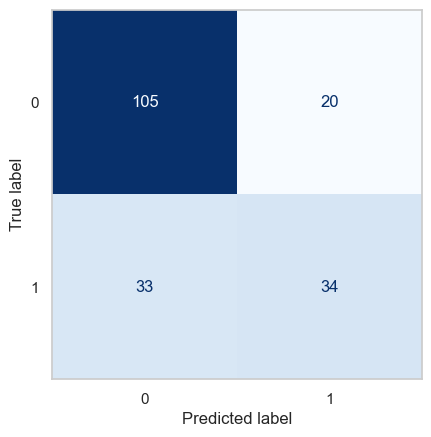

In [ ]:
kol = ["plas", "pres", "skin", "insu", "mass"]
data[kol] = data[kol].replace(0, np.nan)
X = data.drop(columns="diabetes"); y = data["diabetes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

lr = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=2000)).fit(X_train, y_train)
p_test = lr.predict_proba(X_test)[:, 1]
print({k: round(v, 3) for k, v in klassifiserings_metrikker(y_test, (p_test >= 0.5).astype(int)).items()}, " AUC =", round(roc_auc_score(y_test, p_test), 3))
ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= 0.5).astype(int), cmap="Blues", colorbar=False)
plt.grid(False)
plt.show()

sensitivitet bare ca 0.5 – modellen overser omtrent halvparten av dem som har diabetes. For screening er dette sannsyligvis litt for lavt til å akseptere som et screening verktøy

### Oppgave 3 – ROC og terskel
- a) Plott ROC- og PR-kurve for testsettet, og oppgi AUROC og AUPRC-verdi
- b) Kravet er nå en sensitivitet ≥ 85 %. Finn terskelen på valideringsdata fra utviklingssettet, som du så bruker på testsettet.
- c) Rapporter metrikkene på testsettet med den nye terskelen. Har dette gitt noen endring i spesifisitet og presisjon?

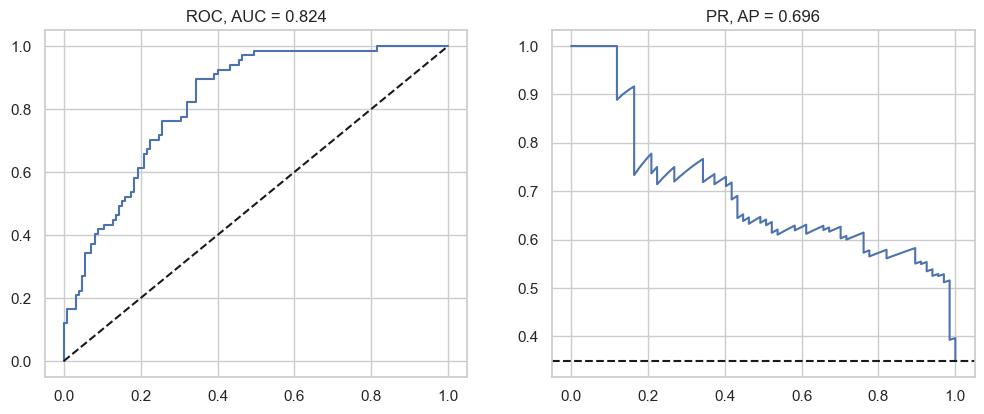

Terskel: 0.239
{'nøyaktighet': np.float64(0.734), 'sensitivitet': np.float64(0.881), 'spesifisitet': np.float64(0.656), 'presisjon': np.float64(0.578), 'F1': np.float64(0.698)}


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(y_test, p_test)
ax[0].plot(fpr, tpr)
ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set_title(f"ROC, AUC = {roc_auc_score(y_test, p_test):.3f}")

pr, rc, _ = precision_recall_curve(y_test, p_test)
ax[1].plot(rc, pr)
ax[1].axhline(y_test.mean(), color="k", ls="--")
ax[1].set_title(f"PR, AP = {average_precision_score(y_test, p_test):.3f}")
plt.show()

oof = cross_val_predict(lr, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
fpr, tpr, terskler = roc_curve(y_train, oof)
t = terskler[np.argmax(tpr >= 0.85)]
print("Terskel:", round(t, 3))
print({k: round(v, 3) for k, v in klassifiserings_metrikker(y_test, (p_test >= t).astype(int)).items()})

Terskelen for ≥ 85 % sensitivitet blir ca. 0.24 og gir sensitivitet på ca 0.88 på testsettet. 

På testsettet faller spesifisiteten fra omtrent 0.84 til 0.66 og presisjonen fra 0.63 til 0.58.  Dvs. omtrent 4 av 10 av de som kalles inn har ikke diabetes. Om det er akseptabelt avhenger av hva en rekke ting som f.eks hva en oppfølgingstest koster mot en oversett diagnose. Legg også merke til at terskelen ble valgt på treningsdata, ikke på testsettet. 

### Oppgave 4 – Sammenlign modeller statistisk
Sammenlign fire varianter med repetert stratifisert 5-fold (5 repetisjoner) på treningsdata, med AUROC som metrikk (velg modeller selv, men kan være lurt å ta noen simple modeller så ikke prosessen tar så lang tid):

- a) Lag et boksplott med skårene fra alle modellene 
- b) Er den beste modellen signifikant bedre enn logistisk regresjon? Bruk gjerne både vanlig paret t-test og Nadeau–Bengios korrigerte test (begynn med å gjøre sammenligning mellom beste og dårligste - hvis ikke forskjell, så er det ikke vits å gjøre med resten)

                  AUC snitt  AUC SD
LogReg                0.839   0.038
LogReg balansert      0.839   0.038
LogReg + SMOTE        0.838   0.038
Random forest         0.834   0.040


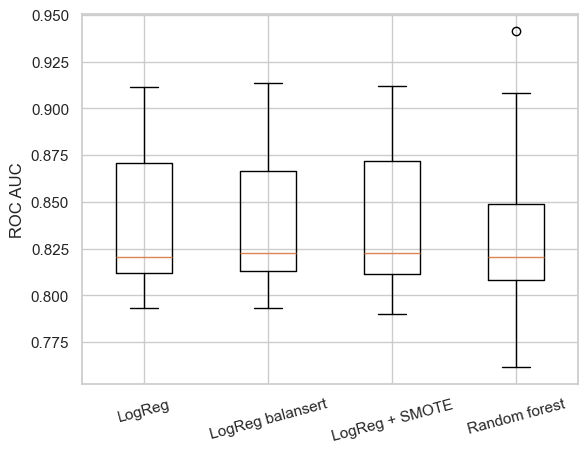

LogReg balansert − LogReg: ΔAUC = +0.0004, naiv p = 0.4641, korrigert p = 0.785


In [ ]:
imp = [SimpleImputer(strategy="median"), StandardScaler()]
modeller = {
    "LogReg": make_pipeline(*imp, LogisticRegression(max_iter=2000)),
    "LogReg balansert": make_pipeline(*imp, LogisticRegression(max_iter=2000, class_weight="balanced")),
    "LogReg + SMOTE": ImbPipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler()), ("smote", SMOTE(random_state=0)), ("m", LogisticRegression(max_iter=2000))]),
    "Random forest": make_pipeline(SimpleImputer(strategy="median"), RandomForestClassifier(200, min_samples_leaf=3, random_state=0)),
}
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)
auc = {n: cross_val_score(m, X_train, y_train, cv=cv, scoring="roc_auc") for n, m in modeller.items()}

print(pd.DataFrame({n: [s.mean(), s.std()] for n, s in auc.items()}, index=["AUC snitt", "AUC SD"]).T.round(3))

plt.boxplot(list(auc.values()), tick_labels=list(auc.keys()))
plt.ylabel("ROC AUC")
plt.xticks(rotation=15)
plt.show()

def korrigert_pval(a, b, ratio=1 / 4):
    """
    Korrigert p-verdi og cohens d
    """
    d = np.asarray(a) - np.asarray(b); J = len(d)
    t = d.mean() / np.sqrt((1 / J + ratio) * d.var(ddof=1))
    return d.mean(), 2 * stats.t.sf(abs(t), J - 1)

beste = max(auc, key=lambda n: auc[n].mean())
_, pk = korrigert_pval(auc[beste], auc["LogReg"])
print(f"{beste} − LogReg: endring i AUROC = {d:+.4f}, p uten korreksjon = {stats.ttest_rel(auc[beste], auc['LogReg']).pvalue:.4f}, korrigert p = {pk:.3f}")

Alle fire modeller ender med AUROC = 0.83–0.84 og SD = 0.04 mellom folds, og forskjellene er forsvinnende små. Konklusjon: vi kan ikke påstå at noen av modellene er bedre enn enkel logistisk regresjon, som man da kan argumentere for er et godt valg, siden den er enklest (og enklest modell er oftest mest forklarbar). 